# Coculture 3/17 — AQuA2 Ca²⁺ Event Analysis
Panels analogous to Fig. 1 of Cahill et al. 2024 (Nature).  
**+ABO** (pink) vs **control** (teal), n = 3 replicates.

| Panel | Content |
|-------|---------|
| a | Placeholder (experimental schematic) |
| b | Placeholder (representative images / AQuA2 event maps) |
| c | Events per time bin — mean ± SEM with error bars |
| d | Area vs Duration scatter, colored by onset frame |
| e | Event count |
| f | Event area |
| g | Amplitude (Max ΔF/F) |

In [1]:
import csv, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats

plt.rcParams.update({
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
})

BASE  = '/home/crnlqz/krenciklab/coculture_3_17_out'
COLOR = {'+ABO': '#E8748A', 'control': '#4DADA0'}

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
SAMPLES = [
    dict(name='rep1_+ABO',    condition='+ABO',    rep=1,
         folder='Coculture_rep1_+ABO_results',
         csv='Coculture_rep1_+ABO_AQuA2_Ch1.csv'),
    dict(name='rep1_control', condition='control', rep=1,
         folder='Coculture_rep1_control_results',
         csv='Coculture_rep1_control_AQuA2_Ch1.csv'),
    dict(name='rep2_+ABO',    condition='+ABO',    rep=2,
         folder='Coculture_rep2_+ABO_results',
         csv='Coculture_rep2_+ABO_AQuA2_Ch1.csv'),
    dict(name='rep2_control', condition='control', rep=2,
         folder='Coculture_rep2+control_results',
         csv='Coculture_rep2+control_AQuA2_Ch1.csv'),
    dict(name='rep3_+ABO',    condition='+ABO',    rep=3,
         folder='Coculture_rep3_+ABO_results',
         csv='Coculture_rep3_+ABO_AQuA2_Ch1.csv'),
    dict(name='rep3_control', condition='control', rep=3,
         folder='Coculture_rep3+control_results',
         csv='Coculture_rep3+control_AQuA2_Ch1.csv'),
]

def parse_csv(path):
    with open(path) as f:
        rows = list(csv.reader(f))
    data = {}
    for row in rows:
        vals = []
        for v in row[1:]:
            try:   vals.append(float(v))
            except: pass
        if vals:
            data[row[0]] = vals
    return data

records = []
for s in SAMPLES:
    path = os.path.join(BASE, s['folder'], s['csv'])
    data = parse_csv(path)
    n = len(next(iter(data.values()))) if data else 0
    for i in range(n):
        records.append({
            'sample':      s['name'],
            'condition':   s['condition'],
            'rep':         s['rep'],
            'event_idx':   i + 1,
            'start_frame': data.get('Starting Frame',                                          [np.nan]*n)[i],
            'area':        data.get('Basic - Area',                                            [np.nan]*n)[i],
            'max_dff':     data.get('Curve - Max Dff',                                         [np.nan]*n)[i],
            'dff_auc':     data.get('Curve - dff AUC',                                         [np.nan]*n)[i],
            'duration50':  data.get('Curve - Duration 50% to 50% based on averge dF/F',        [np.nan]*n)[i],
            'propagation': data.get('Propagation - onset - overall',                           [np.nan]*n)[i],
        })

df = pd.DataFrame(records)

# Per-sample summary (for bar panels)
summary = (
    df.groupby(['condition', 'rep'])
    .agg(n_events=('event_idx','count'), mean_area=('area','mean'),
         mean_dff=('max_dff','mean'),    mean_auc=('dff_auc','mean'),
         mean_prop=('propagation','mean'))
    .reset_index()
)

def cond_stats(metric):
    a = summary[summary.condition=='+ABO'][metric].values.astype(float)
    c = summary[summary.condition=='control'][metric].values.astype(float)
    a, c = a[~np.isnan(a)], c[~np.isnan(c)]
    sem = lambda x: x.std(ddof=1)/np.sqrt(len(x)) if len(x)>1 else 0
    return a, c, a.mean(), c.mean(), sem(a), sem(c)

def pval_label(a, b):
    if len(a)<2 or len(b)<2: return 'n.s.'
    _, p = stats.ttest_ind(a, b)
    return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'

print(df.groupby(['condition','rep']).size().rename('n_events'))

condition  rep
+ABO       1       7
           2       3
           3      10
control    1       2
           3      14
Name: n_events, dtype: int64


## Panel a — Experimental schematic (placeholder)

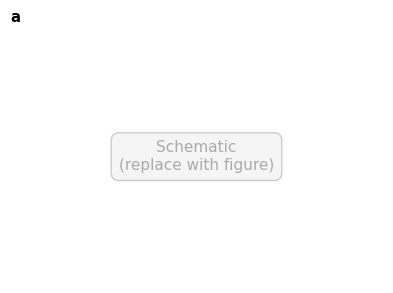

In [3]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.text(0.5, 0.5, 'Schematic\n(replace with figure)', ha='center', va='center',
        fontsize=11, color='#aaaaaa',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5', edgecolor='#cccccc'))
for spine in ax.spines.values(): spine.set_visible(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('a', loc='left', fontweight='bold')
plt.tight_layout()
plt.show()

## Panel b — Representative images / AQuA2 event maps (placeholder)

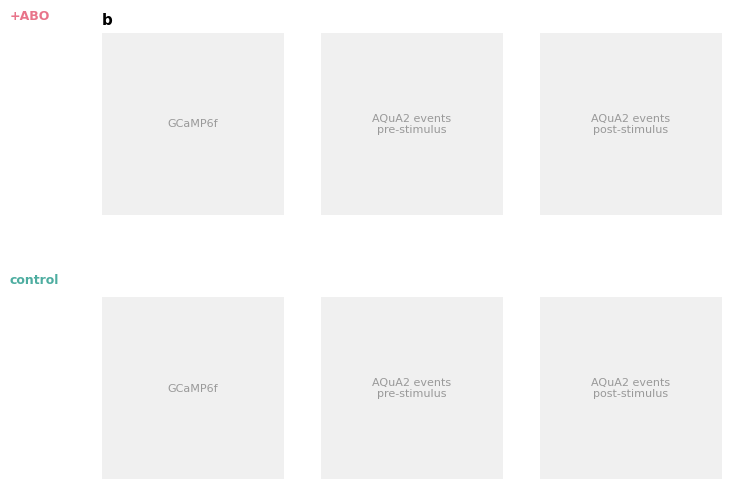

In [4]:
TILE_TITLES = ["GCaMP6f", "AQuA2 events\npre-stimulus", "AQuA2 events\npost-stimulus"]

fig = plt.figure(figsize=(8, 5))
subfigs = fig.subfigures(2, 1, hspace=0.12)

for i, (subfig, cond) in enumerate(zip(subfigs, ["+ABO", "control"])):
    subfig.suptitle(cond, color=COLOR[cond], fontweight="bold", fontsize=9, x=0.01, ha="left")
    axes = subfig.subplots(1, 3)
    for ax, title in zip(axes, TILE_TITLES):
        ax.set_facecolor("#f0f0f0")
        ax.text(0.5, 0.5, title, ha="center", va="center", fontsize=8, color="#999999")
        for spine in ax.spines.values(): spine.set_visible(False)
        ax.set_xticks([]); ax.set_yticks([])
    if i == 0:
        axes[0].set_title("b", loc="left", fontweight="bold")

plt.savefig(os.path.join(BASE, "panel_b_images.pdf"), dpi=300, bbox_inches="tight")
plt.show()


## Panel c — Events over time (mean ± SEM, error bars)

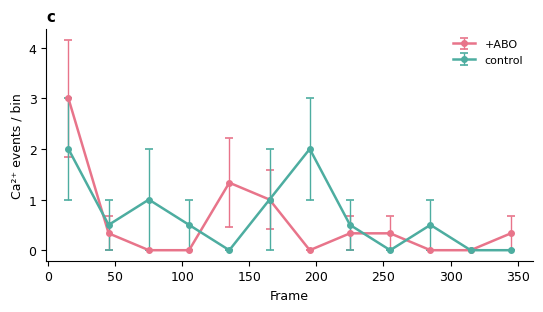

In [5]:
BIN, MAX_FRAME = 30, 360

def bin_events(df_cond, bin_size, max_frame):
    bins = np.arange(0, max_frame + bin_size, bin_size)
    centers = (bins[:-1] + bins[1:]) / 2
    reps = sorted(df_cond['rep'].unique())
    counts = np.zeros((len(reps), len(centers)))
    for j, rep in enumerate(reps):
        frames = df_cond[df_cond['rep']==rep]['start_frame'].dropna().values
        counts[j], _ = np.histogram(frames, bins=bins)
    return centers, counts

fig, ax = plt.subplots(figsize=(5.5, 3.2))

for cond in ['+ABO', 'control']:
    col = COLOR[cond]
    centers, counts = bin_events(df[df.condition==cond], BIN, MAX_FRAME)
    mean_tr = counts.mean(axis=0)
    sem_tr  = counts.std(axis=0, ddof=1) / np.sqrt(counts.shape[0])
    ax.errorbar(centers, mean_tr, yerr=sem_tr,
                color=col, lw=1.8, capsize=3, capthick=1.2,
                elinewidth=1, marker='o', markersize=4,
                label=cond, zorder=3)

ax.set_xlabel('Frame')
ax.set_ylabel('Ca²⁺ events / bin')
ax.set_title('c', loc='left', fontweight='bold')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'panel_c_events_over_time.pdf'), dpi=300, bbox_inches='tight')
plt.show()

## Panel d — Area vs Duration scatter (colored by onset frame)

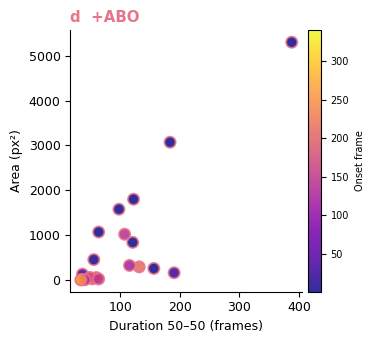

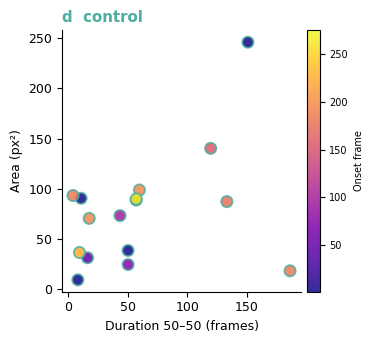

In [6]:
for cond in ["+ABO", "control"]:
    sub = df[df.condition==cond].dropna(subset=["area","duration50","start_frame"])

    fig, ax = plt.subplots(figsize=(3.8, 3.5))
    sc = ax.scatter(
        sub["duration50"], sub["area"],
        c=sub["start_frame"], cmap="plasma",
        s=65, edgecolors=COLOR[cond], linewidths=1.3,
        alpha=0.85, zorder=3,
    )
    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("Onset frame", fontsize=7)
    cbar.ax.tick_params(labelsize=7)
    ax.set_xlabel("Duration 50–50 (frames)")
    ax.set_ylabel("Area (px²)")
    ax.set_title(f"d  {cond}", loc="left", fontweight="bold", color=COLOR[cond])
    plt.tight_layout()
    plt.savefig(os.path.join(BASE, f"panel_d_scatter_{cond.replace("+","plus")}.pdf"), dpi=300, bbox_inches="tight")
    plt.show()


## Panel e — Event count

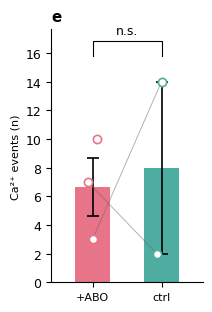

In [7]:
def bar_panel(metric, ylabel, panel_letter, fname):
    a_vals, c_vals, a_mean, c_mean, a_sem, c_sem = cond_stats(metric)
    jitter = np.array([-0.07, 0.0, 0.07])

    fig, ax = plt.subplots(figsize=(2.2, 3.2))
    for xi, vals, mean, sem, cond in [
        (0, a_vals, a_mean, a_sem, '+ABO'),
        (1, c_vals, c_mean, c_sem, 'control')
    ]:
        col = COLOR[cond]
        ax.bar(xi, mean, yerr=sem, color=col, width=0.5,
               capsize=4, error_kw=dict(lw=1.2, capthick=1.2), zorder=2)
        j = jitter[:len(vals)]
        ax.scatter(xi + j, vals, color='white', edgecolors=col,
                   s=35, zorder=4, linewidths=1.2)

    # paired lines
    n_pairs = min(len(a_vals), len(c_vals))
    for k in range(n_pairs):
        ax.plot([0+jitter[k], 1+jitter[k]], [a_vals[k], c_vals[k]],
                color='#666666', lw=0.7, alpha=0.5, zorder=3)

    # significance bracket
    ann = pval_label(a_vals, c_vals)
    ymax = max(np.nanmax(a_vals) if len(a_vals) else 0,
               np.nanmax(c_vals) if len(c_vals) else 0)
    ytop = ymax * 1.2
    ax.plot([0, 0, 1, 1], [ytop*0.94, ytop, ytop, ytop*0.94], lw=0.8, color='k')
    ax.text(0.5, ytop*1.02, ann, ha='center', va='bottom', fontsize=9)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['+ABO', 'ctrl'], fontsize=8)
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(panel_letter, loc='left', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE, fname), dpi=300, bbox_inches='tight')
    plt.show()

bar_panel('n_events', 'Ca²⁺ events (n)', 'e', 'panel_e_event_count.pdf')

## Panel f — Event area

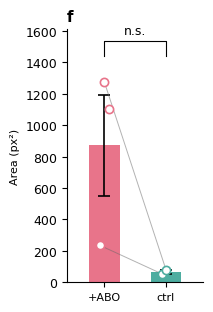

In [8]:
bar_panel('mean_area', 'Area (px²)', 'f', 'panel_f_area.pdf')

## Panel g — Amplitude (Max ΔF/F)

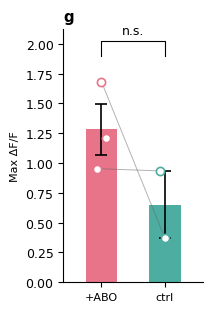

In [9]:
bar_panel('mean_dff', 'Max ΔF/F', 'g', 'panel_g_amplitude.pdf')